<a href="https://colab.research.google.com/github/channel1umut-lang/Machine-Learning-Applications/blob/main/0015_RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
#https://www.kaggle.com/datasets/lodetomasi1995/income-classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/14-income_evaluation.csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
col_names = ['age', 'workclass', 'finalweight', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [ ]:
df.columns = col_names

In [ ]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.00000000,32561.00000000,32561.00000000,32561.00000000,32561.00000000,32561.00000000
mean,38.58164676,189778.36651209,10.08067934,1077.64884371,87.30382973,40.43745585
std,13.64043255,105549.97769702,2.57272033,7385.29208484,402.96021865,12.34742868
min,17.00000000,12285.00000000,1.00000000,0.00000000,0.00000000,1.00000000
25%,28.00000000,117827.00000000,9.00000000,0.00000000,0.00000000,40.00000000
50%,37.00000000,178356.00000000,10.00000000,0.00000000,0.00000000,40.00000000
75%,48.00000000,237051.00000000,12.00000000,0.00000000,0.00000000,45.00000000
max,90.00000000,1484705.00000000,16.00000000,99999.00000000,4356.00000000,99.00000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
finalweight,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
categorical = [col for col in df.columns if df[col].dtype=='O'] # sadece kategorik degerleri yazdirdi
numerical = [col for col in df.columns if df[col].dtype!='O'] # sadece numberik degerleri yazdirdi

In [ ]:
print(categorical)

['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [ ]:
print(numerical)

['age', 'finalweight', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [ ]:
df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [ ]:
for col in categorical: #butun colonlari ayni anda gormek icin
    print(df[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

In [ ]:
df['income'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [ ]:
df['income'].value_counts()

,count
income,
<=50K,24720
>50K,7841


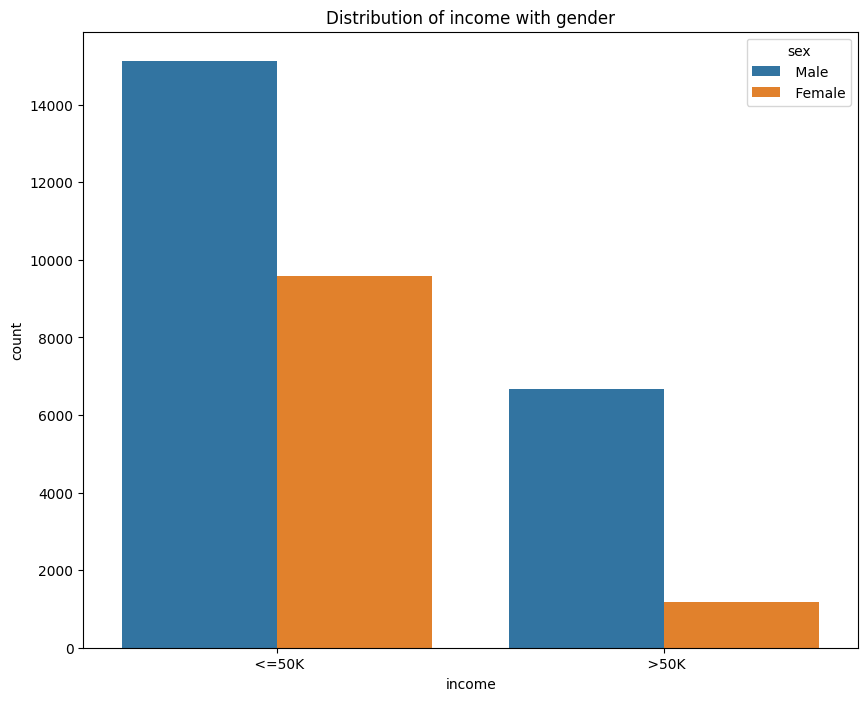

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8)) #fig = içinde grafik olan pencere/tuval , ax = grafiğin kendisi (eksenler, çubuklar, etc.)
ax = sns.countplot(x="income", hue="sex", data=df)
ax.set_title("Distribution of income with gender")
plt.show()

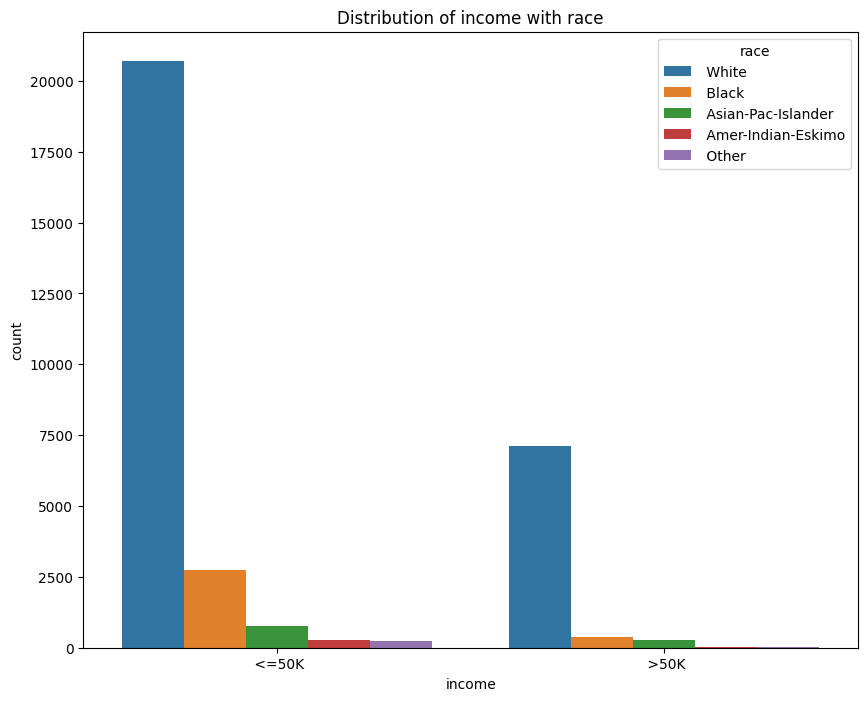

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.countplot(x="income", hue="race", data=df)
ax.set_title("Distribution of income with race")
plt.show()

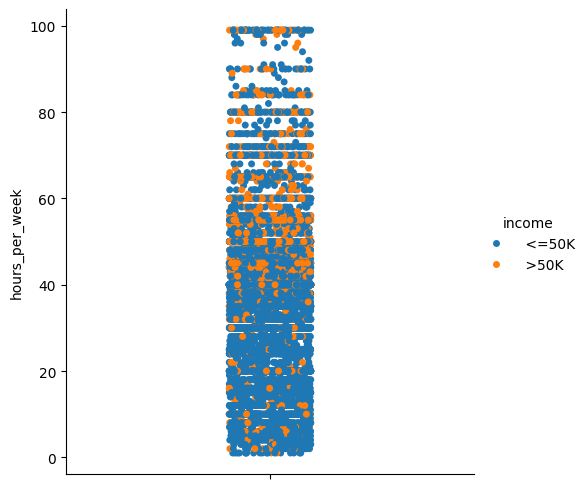

In [ ]:
sns.catplot(y = df['hours_per_week'], hue = df['income']) # is saatleri fazla olan  daha fazla kazaniyor

In [ ]:
#males making more than females
#white making more than other races

In [ ]:
over_40_hours = df[df['hours_per_week']>40] # is saatleri 40dan fazla olanlari getirdi sadece
under_40_hours = df[df['hours_per_week']<40] # is saatleri 40dan az olanlari getirdi sadece

In [ ]:
under_40_hours.shape

(7763, 15)

In [ ]:
over_40_hours

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
10,37,Private,280464,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,80,United-States,>50K
13,32,Private,205019,Assoc-acdm,12,Never-married,Sales,Not-in-family,Black,Male,0,0,50,United-States,<=50K
15,34,Private,245487,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,0,45,Mexico,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32538,38,Private,139180,Bachelors,13,Divorced,Prof-specialty,Unmarried,Black,Female,15020,0,45,United-States,>50K
32543,45,Local-gov,119199,Assoc-acdm,12,Divorced,Prof-specialty,Unmarried,White,Female,0,0,48,United-States,<=50K
32548,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K
32550,43,Self-emp-not-inc,27242,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K


In [ ]:
under_40_hours

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
12,23,Private,122272,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,United-States,<=50K
16,25,Self-emp-not-inc,176756,HS-grad,9,Never-married,Farming-fishing,Own-child,White,Male,0,0,35,United-States,<=50K
21,54,Private,302146,HS-grad,9,Separated,Other-service,Unmarried,Black,Female,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32544,31,Private,199655,Masters,14,Divorced,Other-service,Not-in-family,Other,Female,0,0,30,United-States,<=50K
32545,39,Local-gov,111499,Assoc-acdm,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K


In [ ]:
df['workclass'].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [ ]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df['workclass']=df['workclass'].replace(' ?', np.nan)

In [ ]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df['education'].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [ ]:
df['marital_status'].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [ ]:
df['occupation'].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [ ]:
df['occupation']=df['occupation'].replace(' ?', np.nan)

In [ ]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Transport-moving,1597
Handlers-cleaners,1370


In [ ]:
df['native_country'].unique()

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [ ]:
df['native_country']=df['native_country'].replace(' ?', np.nan)

In [ ]:
df['native_country'].value_counts()

,count
native_country,
United-States,29170
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
df['relationship'].unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [ ]:
df['sex'].unique()

array([' Male', ' Female'], dtype=object)

In [ ]:
df['race'].unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [ ]:
df[categorical].isnull().sum()

,0
workclass,1836
education,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0
native_country,583
income,0


In [ ]:
df[numerical].isnull().sum()

,0
age,0
finalweight,0
education_num,0
capital_gain,0
capital_loss,0
hours_per_week,0


In [ ]:
# we will deal with null values, now let's see some graphs

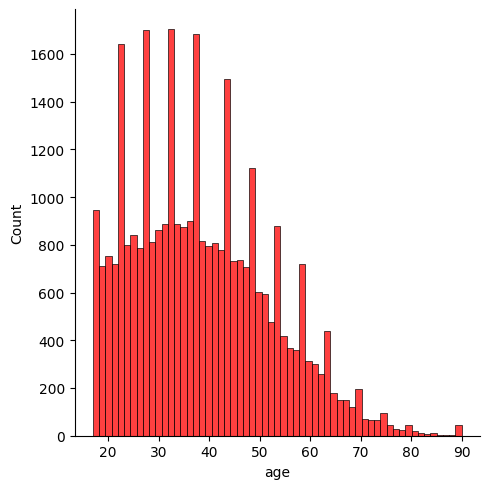

In [ ]:
sns.displot(df['age'], color='red')
plt.show()

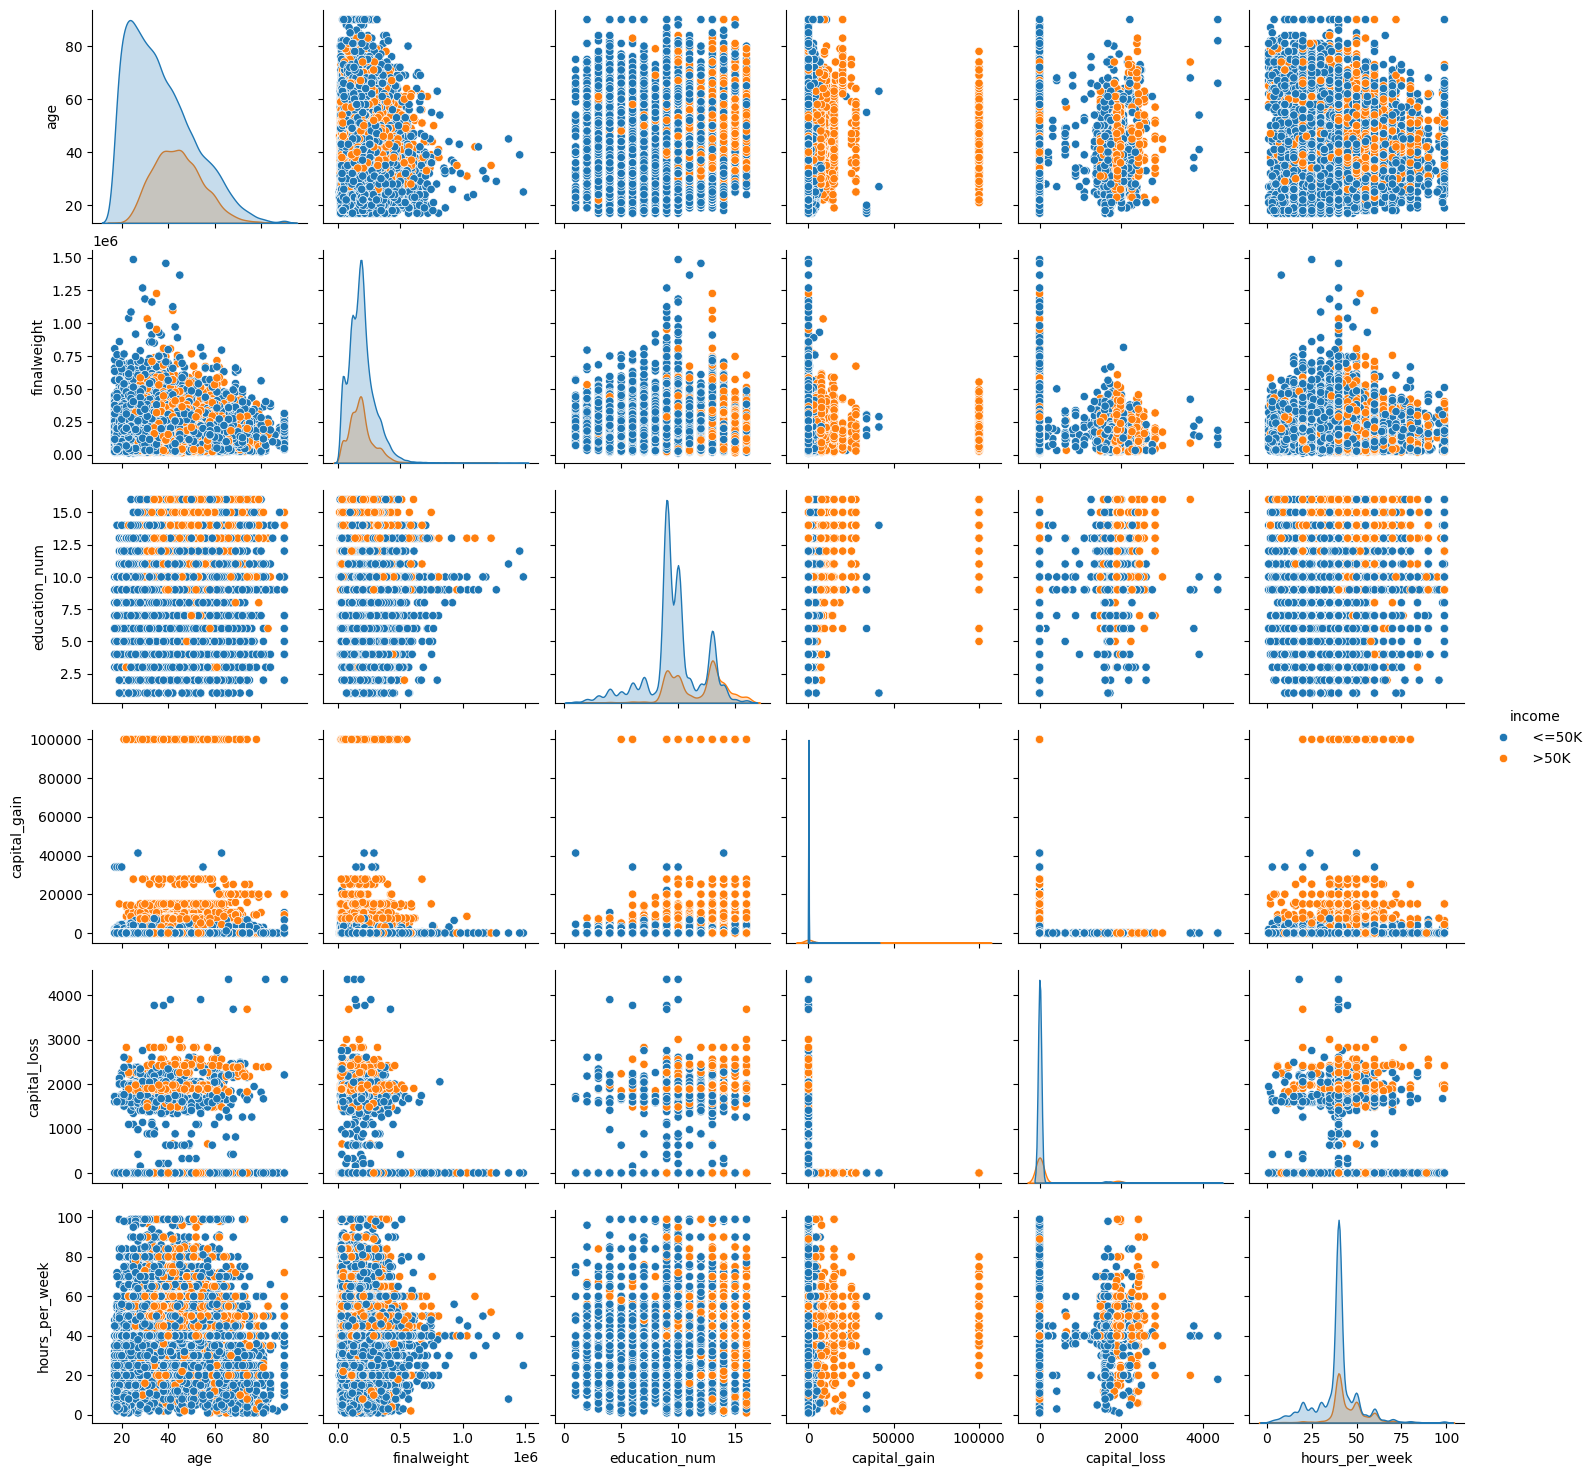

In [ ]:
sns.pairplot(df, hue="income")
plt.show()

In [ ]:
# features

In [ ]:
X = df.drop(['income'], axis=1)
y = df['income']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [ ]:
# i will get categorical columns one more time because income is not with the X now
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

In [ ]:
X_train[categorical].isnull().sum()

,0
workclass,1276
education,0
marital_status,0
occupation,1278
relationship,0
race,0
sex,0
native_country,414


In [ ]:
# there are a lot of missing data so i am going to impute missing data with mode of that categorical variable

In [ ]:
# use mode of X_train rather than X_test to impute

In [ ]:
X_train['workclass'].mode()

,workclass
0,Private


In [ ]:
X_train['workclass'].mode()[0]

' Private'

In [ ]:
for i in [X_train, X_test]:
    i['workclass'] = i['workclass'].fillna(X_train['workclass'].mode()[0]) #bosluklari doldurdu X_traine gore.
    i['occupation'] = i['occupation'].fillna(X_train['occupation'].mode()[0])
    i['native_country'] = i['native_country'].fillna(X_train['native_country'].mode()[0])

In [ ]:
X_train[categorical].isnull().sum()

,0
workclass,0
education,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0
native_country,0


In [ ]:
X_train.isnull().sum()

,0
age,0
workclass,0
finalweight,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
X_test.isnull().sum()

,0
age,0
workclass,0
finalweight,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
# encoding

In [ ]:
X_train[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
32098,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
25206,State-gov,HS-grad,Divorced,Adm-clerical,Unmarried,White,Female,United-States
23491,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,United-States
12367,Private,HS-grad,Never-married,Craft-repair,Not-in-family,White,Male,Guatemala
7054,Private,7th-8th,Never-married,Craft-repair,Not-in-family,White,Male,Germany


In [ ]:
print(df[categorical].nunique())

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
dtype: int64


In [ ]:
# there are many unique values in native_country. if we do one hot encoding it might work but it might get complicated
# because there will be many columns and it may lead to overfitting or underperforming generally
# so i will do target encoding for native country and one hot encoding for the rest.
# for target encoding i will get the mean of every unique value and replace it with them

In [ ]:
# in order to get a mean from income column, i need to make it 1 or 0
y_train_binary = y_train.apply(lambda x: 1 if x.strip() == '>50K' else 0) # .apply(lambda x: ...) Her bir satıra bir fonksiyon uygular..x her seferinde bir satırın değerini temsil eder// .strip() Metnin başındaki ve sonundaki boşlukları temizler

# this will give me the average of 0s and 1s for native countries so i can encode it using these values
target_means = y_train_binary.groupby(X_train['native_country']).mean()## Her kişiye, ülkesinin ortalama gelir oranını ata!!!!!

In [ ]:
target_means

,income
native_country,
Cambodia,0.33333333
Canada,0.30952381
China,0.24137931
Columbia,0.02173913
Cuba,0.25714286
Dominican-Republic,0.02127660
Ecuador,0.16666667
El-Salvador,0.10144928
England,0.29508197


In [ ]:
X_train['native_country_encoded'] = X_train['native_country'].map(target_means) #target_means yukardaki bir degisken
X_train['native_country_encoded'] = X_train['native_country_encoded'].fillna(y_train_binary.mean()) # bos kalanlari da y_train_binary nin ortalamasi neyse onu koyduk

X_test['native_country_encoded'] = X_test['native_country'].map(target_means)
X_test['native_country_encoded'] = X_test['native_country_encoded'].fillna(y_train_binary.mean())

In [ ]:
X_train.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
32098,45,Private,170871,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,60,United-States,0.24572168
25206,47,State-gov,108890,HS-grad,9,Divorced,Adm-clerical,Unmarried,White,Female,1831,0,38,United-States,0.24572168
23491,48,Private,187505,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,0.24572168
12367,29,Private,145592,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Guatemala,0.04166667
7054,23,Private,203003,7th-8th,4,Never-married,Craft-repair,Not-in-family,White,Male,0,0,25,Germany,0.28409091


In [ ]:
X_train = X_train.drop("native_country", axis=1)
X_test = X_test.drop("native_country", axis=1)

In [ ]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [ ]:
# rest will be one hot encoded
one_hot_categories = ['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_categories) # handle_unknown='ignore' bilinmeyen kolononu pas gecer. one_hot_categories = Uygulanacak sütun(lar) sparse_output=False: Sonucu seyrek (sparse) matris yerine normal dizi (array) olarak ver İşlemesi daha kolay olsun diye
    ], #şu kategorik sütunları al, one-hot encoding yap, eğitimde görmeyen kategorileri görmezden gel ve sonucu normal dizi olarak ver
    remainder='passthrough'  # leave the rest of the columns as it is
)

# Fit-transform
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [ ]:
# this gives X_train as numpy array if you want to turn this into df you have to get column names

In [ ]:
X_train_enc

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        60.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        38.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        50.        ,  0.24572168],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24572168],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        45.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        48.        ,  0.24572168]])

In [ ]:
# get all encoded column names
columns = encoder.get_feature_names_out()

In [ ]:
columns

array(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th',
       'cat__education_ 12th', 'cat__education_ 1st-4th',
       'cat__education_ 5th-6th', 'cat__education_ 7th-8th',
       'cat__education_ 9th', 'cat__education_ Assoc-acdm',
       'cat__education_ Assoc-voc', 'cat__education_ Bachelors',
       'cat__education_ Doctorate', 'cat__education_ HS-grad',
       'cat__education_ Masters', 'cat__education_ Preschool',
       'cat__education_ Prof-school', 'cat__education_ Some-college',
       'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-mar

In [ ]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [ ]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
32098,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,45.00000000,170871.00000000,9.00000000,7298.00000000,0.00000000,60.00000000,0.24572168
25206,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,1.00000000,0.00000000,47.00000000,108890.00000000,9.00000000,1831.00000000,0.00000000,38.00000000,0.24572168
23491,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,48.00000000,187505.00000000,10.00000000,0.00000000,0.00000000,50.00000000,0.24572168
12367,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,29.00000000,145592.00000000,9.00000000,0.00000000,0.00000000,40.00000000,0.04166667
7054,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,23.00000000,203003.00000000,4.00000000,0.00000000,0.00000000,25.00000000,0.28409091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,43.00000000,33331.00000000,14.00000000,0.00000000,0.00000000,40.00000000,0.24572168
19648,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,44.00000000,98466.00000000,6.00000000,0.00000000,0.00000000,35.00000000,0.24572168
9845,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,1.00000000,0.00000000,23.00000000,45317.00000000,10.00000000,0.00000000,0.00000000,40.00000000,0.24572168
10799,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,45.00000000,215862.00000000,16.00000000,7688.00000000,0.00000000,45.00000000,0.24572168


In [ ]:
X_test

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
22278,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,1.00000000,0.00000000,27.00000000,177119.00000000,10.00000000,0.00000000,0.00000000,44.00000000,0.24572168
8950,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,1.00000000,0.00000000,27.00000000,216481.00000000,13.00000000,0.00000000,0.00000000,40.00000000,0.24572168
7838,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,25.00000000,256263.00000000,12.00000000,0.00000000,0.00000000,40.00000000,0.24572168
16505,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,1.00000000,46.00000000,147640.00000000,3.00000000,0.00000000,1902.00000000,40.00000000,0.24572168
19140,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,...,1.00000000,0.00000000,1.00000000,45.00000000,172822.00000000,7.00000000,0.00000000,2824.00000000,76.00000000,0.24572168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21949,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,1.00000000,46.00000000,192963.00000000,13.00000000,0.00000000,2415.00000000,35.00000000,0.32800000
26405,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.00000000,1.00000000,64.00000000,388594.00000000,15.00000000,15024.00000000,0.00000000,45.00000000,0.24572168
23236,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,1.00000000,54.00000000,304570.00000000,13.00000000,7688.00000000,0.00000000,40.00000000,0.24572168
26823,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,1.00000000,0.00000000,36.00000000,90159.00000000,10.00000000,0.00000000,0.00000000,40.00000000,0.24572168


In [ ]:
# we don't actually need scaling in dt algortihms but let's do it because we will introduce robust scaler

In [ ]:
# robust scaler is different than standardscaler and it is designed to handle outliers.

In [ ]:
X_train.columns

Index(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th', 'cat__education_ 12th',
       'cat__education_ 1st-4th', 'cat__education_ 5th-6th',
       'cat__education_ 7th-8th', 'cat__education_ 9th',
       'cat__education_ Assoc-acdm', 'cat__education_ Assoc-voc',
       'cat__education_ Bachelors', 'cat__education_ Doctorate',
       'cat__education_ HS-grad', 'cat__education_ Masters',
       'cat__education_ Preschool', 'cat__education_ Prof-school',
       'cat__education_ Some-college', 'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-married', 

In [ ]:
cols = X_train.columns

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# we don't have to convert X_train into df again, we can just give it as a numpy array to model but
# if we want to use column names again later it will come in handy
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [ ]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.40000000,-0.05890618,-0.33333333,7298.00000000,0.00000000,4.00000000,0.00000000
1,0.00000000,0.00000000,0.00000000,-1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,1.00000000,-1.00000000,0.50000000,-0.57807635,-0.33333333,1831.00000000,0.00000000,-0.40000000,0.00000000
2,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.55000000,0.08042484,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000
3,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,-0.40000000,-0.27065015,-0.33333333,0.00000000,0.00000000,0.00000000,-0.20405501
4,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,-0.70000000,0.21024042,-2.00000000,0.00000000,0.00000000,-3.00000000,0.03836923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22787,0.00000000,1.00000000,0.00000000,-1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.30000000,-1.21097963,1.33333333,0.00000000,0.00000000,0.00000000,0.00000000
22788,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.35000000,-0.66539068,-1.33333333,0.00000000,0.00000000,-1.00000000,0.00000000
22789,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,1.00000000,-1.00000000,-0.70000000,-1.11058154,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
22790,0.00000000,1.00000000,0.00000000,-1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.40000000,0.31795099,2.00000000,7688.00000000,0.00000000,1.00000000,0.00000000


In [ ]:
#training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=10, random_state=15) #10 tane agaci paralel egitiyor ortalamasini aliyor.
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=15)

In [ ]:
y_pred = rfc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(f'Model accuracy score with 10 decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with 10 decision-trees : 0.8470672535571706


In [ ]:
# instantiate the classifier with n_estimators = 100
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.8537209540382844


In [ ]:
# let's try to see feature importance

In [ ]:
rfc.feature_importances_

array([5.89915888e-03, 5.82375187e-03, 7.14292998e-06, 1.12395409e-02,
       5.45950100e-03, 9.14446600e-03, 4.95867851e-03, 7.49970941e-05,
       1.26676685e-03, 1.78936666e-03, 8.44081442e-04, 2.49805089e-04,
       3.53321264e-04, 1.49032443e-03, 1.07900514e-03, 2.45097237e-03,
       3.15104569e-03, 1.08197880e-02, 2.65277844e-03, 6.84630198e-03,
       7.92194647e-03, 2.85857892e-05, 4.02750221e-03, 5.92388104e-03,
       6.13768337e-03, 2.84733479e-04, 6.17521057e-02, 9.80661116e-04,
       2.54875412e-02, 1.67947319e-03, 1.71908968e-03, 5.54312037e-03,
       2.27790711e-05, 8.36620649e-03, 1.89641500e-02, 3.77276733e-03,
       3.09264886e-03, 4.42875165e-03, 7.56797784e-03, 9.70846089e-05,
       1.37068011e-02, 3.06774138e-03, 7.40362575e-03, 5.15548967e-03,
       5.31269539e-03, 4.44090385e-02, 9.48837044e-03, 1.44590705e-03,
       9.48597008e-03, 4.50150645e-03, 1.01949978e-02, 1.37613012e-03,
       3.39643432e-03, 4.90775153e-03, 8.37231704e-04, 7.03575103e-03,
      

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False) # kolonlarin onem sirasi

In [ ]:
feature_scores

,0
remainder__finalweight,0.15994566
remainder__age,0.14862913
remainder__capital_gain,0.09596091
remainder__hours_per_week,0.08459239
remainder__education_num,0.07124529
...,...
cat__occupation_ Priv-house-serv,0.00009708
cat__workclass_ Without-pay,0.00007500
cat__education_ Preschool,0.00002859
cat__occupation_ Armed-Forces,0.00002278


In [ ]:
pd.set_option('display.float_format', '{:.8f}'.format)

In [ ]:
feature_scores

,0
remainder__finalweight,0.15994566
remainder__age,0.14862913
remainder__capital_gain,0.09596091
remainder__hours_per_week,0.08459239
remainder__education_num,0.07124529
...,...
cat__occupation_ Priv-house-serv,0.00009708
cat__workclass_ Without-pay,0.00007500
cat__education_ Preschool,0.00002859
cat__occupation_ Armed-Forces,0.00002278


In [ ]:
feature_scores.tail(10)

,0
cat__education_ 12th,0.00084408
cat__race_ Other,0.00083723
cat__education_ 5th-6th,0.00035332
cat__marital_status_ Married-AF-spouse,0.00028473
cat__education_ 1st-4th,0.00024981
cat__occupation_ Priv-house-serv,0.00009708
cat__workclass_ Without-pay,0.00007500
cat__education_ Preschool,0.00002859
cat__occupation_ Armed-Forces,0.00002278
cat__workclass_ Never-worked,0.00000714


In [ ]:
# drop the least important 10 columns from train, test and try again
# generally you do not need to do this manually but if you think you somehow made too many columns with encoding
# it's worth a try

In [ ]:
X_train = X_train.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occupation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

/tmp/ipykernel_564/1702574710.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_train = X_train.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",


In [ ]:
X_test = X_test.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occupation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

/tmp/ipykernel_564/466099116.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_test = X_test.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",


In [ ]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.853618589415498


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[6864  543]
 [ 887 1475]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [ ]:
## Hyperparameter Tuning

In [ ]:
rf_params = {"max_depth": [5, 8, 15, None, 10],# Ağaçların ne kadar derin büyüyebileceği
             "max_features": [5, 7, "auto", 8], # max_features = 3 Her dalda RASTGELE 3 özellik seç, sadece onlara bak
             "min_samples_split": [2, 8, 15, 20], # Özet: min_samples_split, bir düğümün "Daha fazla bölünmeye değer mi?" sorusunun cevabı. Eğer yeterli örnek yoksa, o düğüm artık bölünmez ve bir yaprak (leaf) node olarak kalır.
             "n_estimators": [100, 200, 500, 1000]} # agac sayisi
"""
  min_samples_split
   [100 kişi]
        /        \
    [40]        [60]
    /  \        /  \
 [20] [20]   [30] [30]
 / \   / \    / \   / \
[5][15][8][12][10][20][15][15]
                         ↑
                     15 ≥ 4? EVET
                     AMMA! BURADA DUR!
                     NEDEN? Çünkü  min_samples_split i 4 sectik
"""

<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_564/104271046.py:10: SyntaxWarning: invalid escape sequence '\ '
  /  \        /  \


'\n  min_samples_split\n   [100 kişi]\n        /            [40]        [60]\n    /  \\        /   [20] [20]   [30] [30]\n / \\   / \\    / \\   / [5][15][8][12][10][20][15][15]\n                         ↑\n                     15 ≥ 4? EVET\n                     AMMA! BURADA DUR!\n                     NEDEN? Çünkü  min_samples_split i 4 sectik\n'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
rfc = RandomForestClassifier()
rscv = RandomizedSearchCV(estimator=rfc, param_distributions=rf_params,n_iter=10,cv=3,verbose=2,n_jobs=-1)
rscv.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_pa

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 15, None, 10],
                                        'max_features': [5, 7, 'auto', 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200, 500, 1000]},
                   verbose=2)

In [ ]:
y_pred = rscv.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

In [ ]:
rscv.best_params_

{'n_estimators': 200,
 'min_samples_split': 20,
 'max_features': 7,
 'max_depth': None}

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[6864  543]
 [ 887 1475]]
